In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('../data/Bucharest_HousePriceDataset.csv')
df.head()

,Nr Camere,Suprafata,Etaj,Total Etaje,Sector,Scor,Pret
0,4,108.00,2,3,4,5,83000
1,1,41.00,1,8,1,1,39900
2,3,63.52,1,3,2,3,84900
3,1,33.00,3,10,5,1,45500
4,2,62.00,5,9,5,5,54900


In [66]:
print("Shape:", df.shape)
print("\nMissing Values:")
print(df.isnull().sum())

print("\nInfo:")
df.info()

Shape: (3529, 7)

Missing Values:
Nr Camere      0
Suprafata      0
Etaj           0
Total Etaje    0
Sector         0
Scor           0
Pret           0
dtype: int64

Info:
<class 'pandas.DataFrame'>
RangeIndex: 3529 entries, 0 to 3528
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Nr Camere    3529 non-null   int64  
 1   Suprafata    3529 non-null   float64
 2   Etaj         3529 non-null   int64  
 3   Total Etaje  3529 non-null   int64  
 4   Sector       3529 non-null   int64  
 5   Scor         3529 non-null   int64  
 6   Pret         3529 non-null   int64  
dtypes: float64(1), int64(6)
memory usage: 193.1 KB


In [67]:
df = df.rename(columns={
    "Nr Camere": "rooms",
    "Suprafata": "area",
    "Etaj": "floor",
    "Total Etaje": "total_floors",
    "Sector": "sector",
    "Scor": "score",
    "Pret": "price"
})

df.head()

,rooms,area,floor,total_floors,sector,score,price
0,4,108.00,2,3,4,5,83000
1,1,41.00,1,8,1,1,39900
2,3,63.52,1,3,2,3,84900
3,1,33.00,3,10,5,1,45500
4,2,62.00,5,9,5,5,54900


In [68]:
df = df.dropna()
df = df.drop_duplicates()

df = df[
    (df["rooms"] > 0) &
    (df["total_floors"] > 0) &
    (df["area"] > 0) &
    (df["floor"] > 0) &
    (df["price"] > 0) &
    (df["score"] > 0) &
    (df["sector"] > 0)
]

df.head()

,rooms,area,floor,total_floors,sector,score,price
0,4,108.00,2,3,4,5,83000
1,1,41.00,1,8,1,1,39900
2,3,63.52,1,3,2,3,84900
3,1,33.00,3,10,5,1,45500
4,2,62.00,5,9,5,5,54900


In [69]:
df = df[df["price"] < df["price"].quantile(0.99)]

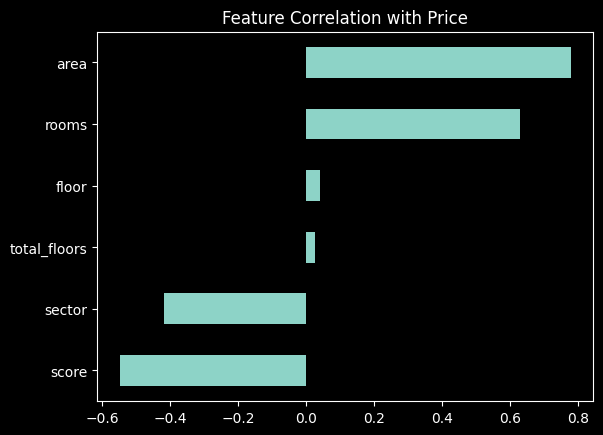

In [70]:
corr = df.corr(numeric_only=True)

corr["price"].drop("price").sort_values().plot(kind="barh")
plt.title("Feature Correlation with Price")
plt.show()

In [71]:
df["is_top_floor"] = (df["floor"] == df["total_floors"]).astype(int)
df["floor_ratio"] = df["floor"] / df["total_floors"]

In [72]:
X = df[[
    "rooms",
    "area",
    "floor",
    "total_floors",
    "sector",
    "score",
    "is_top_floor",
    "floor_ratio"
]]

y = df["price"]

In [73]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [74]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [75]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [76]:
predictions = model.predict(X_test)
predictions[:10]

array([ 30357.58773457, 145382.70479604, 111581.75934562, 114105.90074646,
        90021.23377797, 136236.84182559,  76903.31889515,  69562.90793023,
       124599.88254091,  44934.68203375])

In [77]:
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predictions)

print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)

MSE: 715832032.0757425
RMSE: 26755.03750839723
R2: 0.7277260021876801


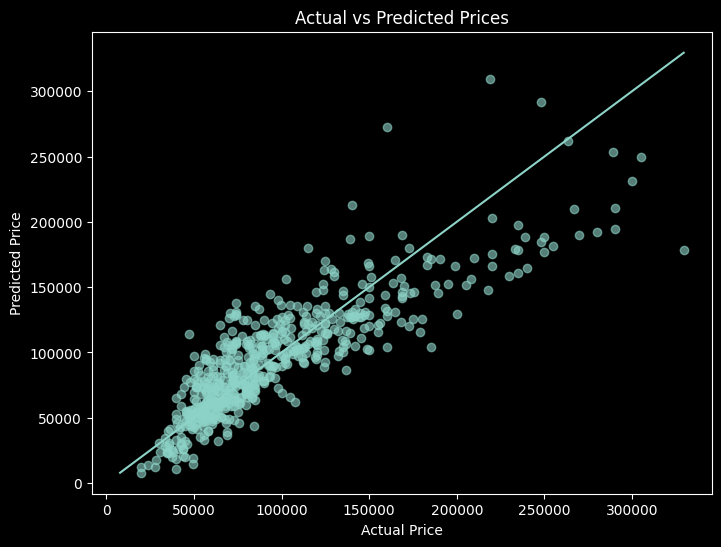

In [78]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, predictions, alpha=0.6)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")

min_val = min(y_test.min(), predictions.min())
max_val = max(y_test.max(), predictions.max())
plt.plot([min_val, max_val], [min_val, max_val])

plt.show()

In [79]:
coefficients = pd.Series(model.coef_, index=[
    "rooms",
    "area",
    "floor",
    "total_floors",
    "sector",
    "score",
    "is_top_floor",
    "floor_ratio"
])

coefficients.sort_values()


score          -16215.326257
floor           -8072.482028
sector          -5525.518204
is_top_floor    -2429.184083
rooms             475.430487
floor_ratio      7301.509900
total_floors     8859.445625
area            36947.359724
dtype: float64

In [80]:
new_apartment = pd.DataFrame([{
    "rooms": 3,
    "area": 80,
    "floor": 4,
    "total_floors": 10,
    "sector": 2,
    "score": 8,
    "is_top_floor": 0,
    "floor_ratio": 4/10
}])

new_apartment = scaler.transform(new_apartment)

predicted_price = model.predict(new_apartment)
print("Predicted price:", predicted_price[0])

Predicted price: 64254.790407593675
